In [1]:
import sys
import os
import re
import json
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import HTML, display
import html

import torch
from transformers import pipeline
from tqdm.auto import tqdm
from datasets import load_dataset

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_prepared_splits
from src.utils import (
    highlight_spans,
    make_json_serializable,
    mask_spans_in_text,
    predict_with_pipeline,
    trim_char_span,
)

In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Class labels used by the Hugging Face classifier
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Inference settings
MAX_LENGTH = 512
BATCH_SIZE = 16
if torch.cuda.is_available():
    TORCH_DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    TORCH_DEVICE = torch.device("mps")
else:
    TORCH_DEVICE = torch.device("cpu")

DEVICE = TORCH_DEVICE

# Attention settings
ATTENTION_METHODS = ["last_cls", "rollout"]
QUANTILE_VALUES = [0.3, 0.4, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
WINDOW_SIZE_VALUES = [0, 1, 2, 3]

# Output
BASE_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = BASE_DIR / "attention_results"
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Pipeline device:", DEVICE)
print("Torch device:", TORCH_DEVICE)

Pipeline device: mps
Torch device: mps


In [3]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
model = pipe.model
model.to(TORCH_DEVICE)
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

print("Mask token:", MASK_TOKEN)
print("Model labels:", model.config.id2label)

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Mask token: [MASK]
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}


# Load prepared data

In [4]:
df_all, train_df, val_df, test_df = load_prepared_splits()

print("All:", df_all.shape)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

All: (2191, 30)
Train: (1533, 30)
Validation: (220, 30)
Test: (438, 30)
Train confusion types:


confusion_type
TP    785
TN    652
FN     48
FP     48
Name: count, dtype: int64

Validation confusion types:


confusion_type
TP    88
TN    66
FN    36
FP    30
Name: count, dtype: int64

Test confusion types:


confusion_type
TP    186
TN    142
FP     71
FN     39
Name: count, dtype: int64

# Attention-based span localization

This notebook evaluates attention-based span localization for the document-level inappropriateness classifier.

The method uses only `post_text` as input. It extracts candidate spans from internal attention distributions and validates them by masking the extracted spans and measuring the resulting drop in the predicted probability of the inappropriate class.

Two attention aggregation strategies are compared:

- `last_cls`: Uses the final transformer layer and averages the attention heads from the classification token to all input tokens. This is a simple raw-attention strategy.
- `rollout`: Aggregates attention across layers by multiplying normalized attention matrices with residual connections. This follows the intuition of Attention Rollout, which estimates how information flows through multiple transformer layers.

Attention is used here only as a candidate-generation signal, not as a faithful explanation by itself. Prior work has shown that attention weights should not automatically be interpreted as explanations of model predictions. Therefore, the extracted spans are validated through perturbation masking.

References:
- Jain and Wallace (2019): *Attention is not Explanation*
- Abnar and Zuidema (2020): *Quantifying Attention Flow in Transformers*

## Quantile and window size

The attention-based approach extracts spans in two steps: first, it selects tokens with high attention scores, and second, it merges nearby selected tokens into spans.

### Quantile

The `quantile` controls how selective the method is when choosing tokens based on their attention scores. For each argument, the attention scores of all valid text tokens are considered and a quantile threshold is computed.

For example:

- `quantile = 0.80` selects tokens in the top 20% of the attention-score distribution.
- `quantile = 0.90` selects tokens in the top 10%.
- `quantile = 0.95` selects only the top 5%.

Thus, higher quantiles usually produce shorter and more focused spans, while lower quantiles produce longer and more inclusive spans.

Example:

Assume an argument has the following simplified token-level attention scores:

| Token | Score |
|---|---:|
| I | 0.01 |
| think | 0.03 |
| you | 0.12 |
| are | 0.04 |
| wrong | 0.15 |
| because | 0.02 |

With a high quantile, for example `quantile = 0.90`, only the strongest tokens such as `you` and `wrong` may be selected. With a lower quantile, more surrounding tokens may also be selected.

### Window size

In this notebook, `window_size` is used as a merge-gap parameter. It does **not** add a fixed number of tokens to the left and right of each selected token. Instead, it determines how many unselected tokens may lie between selected tokens for them to be merged into one span.

For example:

```text
selected_token   unselected_token   selected_token

In [5]:
@torch.no_grad()
def get_attention_data(text, method="rollout", max_length=MAX_LENGTH):
    """
    Compute token-level attention scores for one text.
    
    method:
    - "last_cls": final-layer CLS attention averaged over heads
    - "rollout": attention rollout across all transformer layers
    
    Returns tokenizer tokens, character offsets, valid token mask, and normalized scores.
    """
    enc = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_special_tokens_mask=True,
        return_tensors="pt"
    )
    
    offset_mapping = enc.pop("offset_mapping")[0].tolist()
    special_tokens_mask = enc.pop("special_tokens_mask")[0].tolist()
    
    input_ids = enc["input_ids"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    
    enc = {k: v.to(TORCH_DEVICE) for k, v in enc.items()}
    
    outputs = model(**enc, output_attentions=True)
    attentions = outputs.attentions
    
    if attentions is None:
        raise ValueError("No attentions returned. Check whether output_attentions=True is supported.")
    
    # Each layer has shape: (batch, heads, seq_len, seq_len)
    attn_layers = [a[0].detach().cpu() for a in attentions]
    seq_len = attn_layers[0].shape[-1]
    cls_idx = 0
    
    if method == "last_cls":
        # Final layer, averaged over heads, CLS row.
        A = attn_layers[-1].mean(dim=0)
        scores = A[cls_idx].numpy()
    
    elif method == "rollout":
        # Attention rollout: average heads, add residual identity, row-normalize, multiply through layers.
        result = torch.eye(seq_len)
        
        for layer_attn in attn_layers:
            A = layer_attn.mean(dim=0)
            A = A + torch.eye(seq_len)
            A = A / A.sum(dim=-1, keepdim=True)
            result = A @ result
        
        scores = result[cls_idx].numpy()
    
    else:
        raise ValueError("method must be 'last_cls' or 'rollout'")
    
    valid_token_mask = []
    
    for i, (start, end) in enumerate(offset_mapping):
        is_real_text_token = (
            special_tokens_mask[i] == 0
            and end > start
            and start >= 0
            and end <= len(text)
        )
        valid_token_mask.append(is_real_text_token)
    
    valid_token_mask = np.array(valid_token_mask, dtype=bool)
    scores = np.array(scores, dtype=float)
    
    # Ignore special tokens.
    scores[~valid_token_mask] = 0.0
    
    # Normalize scores over real text tokens.
    total = scores[valid_token_mask].sum()
    if total > 0:
        scores = scores / total
    
    return {
        "text": text,
        "tokens": tokens,
        "offset_mapping": offset_mapping,
        "valid_token_mask": valid_token_mask,
        "attention_scores": scores,
        "method": method
    }

In [6]:
# Example
example_text = val_df.iloc[0][TEXT_COL]
example_pred = predict_with_pipeline(
    texts=[example_text],
    classifier=pipe,
    inappropriate_label=INAPPROPRIATE_LABEL,
    batch_size=BATCH_SIZE,
)
attn_data = get_attention_data(example_text, method="rollout")

pd.DataFrame({
    "token": attn_data["tokens"],
    "offset": attn_data["offset_mapping"],
    "valid": attn_data["valid_token_mask"],
    "score": attn_data["attention_scores"]
}).head(20)

Classifier inference:   0%|          | 0/1 [00:00<?, ?it/s]

,token,offset,valid,score
0,[CLS],"[0, 0]",False,0.000000
1,▁The,"[0, 3]",True,0.026088
2,▁only,"[3, 8]",True,0.011467
3,▁other,"[8, 14]",True,0.008776
4,▁choices,"[14, 22]",True,0.010174
5,▁are,"[22, 26]",True,0.018643
6,",","[26, 27]",True,0.036741
7,▁adoption,"[27, 36]",True,0.011849
8,▁or,"[36, 39]",True,0.016103
9,▁keep,"[39, 44]",True,0.008445


In [7]:
def selected_token_indices(attn_data, quantile):
    """Select valid tokens whose attention score is above the given quantile."""
    scores = attn_data["attention_scores"]
    valid = attn_data["valid_token_mask"]
    
    valid_scores = scores[valid]
    
    if len(valid_scores) == 0:
        return []
    
    threshold = np.quantile(valid_scores, quantile)
    selected = np.where((scores >= threshold) & valid)[0].tolist()
    
    return selected


def build_spans_from_selected_tokens(attn_data, selected_indices, window_size):
    """
    Build merged spans from selected attention tokens.
    
    In this attention setup, window_size is a merge-gap parameter:
    - window_size=0 merges only directly adjacent selected tokens.
    - window_size=1 also merges selected tokens with one unselected token in between.
    - window_size=2 allows up to two unselected tokens in between.
    
    This is not a symmetric left/right expansion as in the TF-IDF baseline.
    """
    text = attn_data["text"]
    tokens = attn_data["tokens"]
    offsets = attn_data["offset_mapping"]
    scores = attn_data["attention_scores"]
    
    if not selected_indices:
        return []
    
    selected_indices = sorted(selected_indices)
    
    groups = []
    current = [selected_indices[0]]
    
    for idx in selected_indices[1:]:
        previous = current[-1]
        
        if idx - previous <= window_size + 1:
            current.append(idx)
        else:
            groups.append(current)
            current = [idx]
    
    groups.append(current)
    
    spans = []
    
    for group in groups:
        token_start_idx = min(group)
        token_end_idx = max(group)
        
        char_start = offsets[token_start_idx][0]
        char_end = offsets[token_end_idx][1]
        char_start, char_end = trim_char_span(text, char_start, char_end)
        
        if char_end <= char_start:
            continue
        
        token_range = list(range(token_start_idx, token_end_idx + 1))
        selected_in_span = [idx for idx in group]
        
        spans.append({
            "char_start": int(char_start),
            "char_end": int(char_end),
            "token_start_idx": int(token_start_idx),
            "token_end_idx": int(token_end_idx),
            "span_text": text[char_start:char_end],
            "span_len_chars": int(char_end - char_start),
            "span_len_tokens": int(token_end_idx - token_start_idx + 1),
            "selected_token_indices": selected_in_span,
            "selected_token_texts": [tokens[idx] for idx in selected_in_span],
            "span_score_sum_attention": float(scores[selected_in_span].sum()),
            "span_score_mean_attention": float(scores[selected_in_span].mean()),
            "span_score_max_attention": float(scores[selected_in_span].max())
        })
    
    for span_idx, span in enumerate(spans):
        span["span_idx"] = int(span_idx)
    
    return spans

In [8]:
def run_attention_config_on_indices(
    df,
    matrix_positions,
    attention_methods,
    quantile_values,
    window_size_values,
    mask_token=MASK_TOKEN
):
    """
    Run attention span extraction and perturbation scoring.
    
    matrix_positions are split-local positions into df.
    global_row_id is stored as the stable identifier for downstream comparison.
    """
    all_results = []
    masked_texts_to_score = []
    masked_lookup = []
    
    for matrix_pos in tqdm(matrix_positions, desc="Building attention spans"):
        row = df.iloc[matrix_pos]
        
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])
        
        for method in attention_methods:
            try:
                attn_data = get_attention_data(
                    text=text,
                    method=method,
                    max_length=MAX_LENGTH
                )
                
                n_model_tokens = int(attn_data["valid_token_mask"].sum())
                
                for quantile in quantile_values:
                    selected_indices = selected_token_indices(
                        attn_data=attn_data,
                        quantile=quantile
                    )
                    
                    for window_size in window_size_values:
                        merged_spans = build_spans_from_selected_tokens(
                            attn_data=attn_data,
                            selected_indices=selected_indices,
                            window_size=window_size
                        )
                        
                        masked_text = mask_spans_in_text(
                            text=text,
                            spans=merged_spans,
                            mask_token=mask_token
                        )
                        
                        total_masked_tokens = sum(
                            span["span_len_tokens"]
                            for span in merged_spans
                        )
                        total_masked_chars = sum(
                            span["span_len_chars"]
                            for span in merged_spans
                        )
                        
                        masked_token_ratio = (
                            total_masked_tokens / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        selected_token_ratio = (
                            len(selected_indices) / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        result = {
                            "global_row_id": int(row["global_row_id"]),
                            "split": row["split"],
                            "post_id": row[ID_COL] if ID_COL in df.columns else None,
                            "issue": row["issue"] if "issue" in df.columns else None,
                            
                            "label": label,
                            "predicted_label": row["predicted_label"],
                            "predicted_score": float(row["predicted_score"]),
                            "confusion_type": row["confusion_type"],
                            "is_true_positive": bool(row["is_true_positive"]),
                            "is_false_negative": bool(row["is_false_negative"]),
                            "is_false_positive": bool(row["is_false_positive"]),
                            "is_true_negative": bool(row["is_true_negative"]),
                            
                            "attention_method": method,
                            "quantile": float(quantile),
                            "window_size": int(window_size),
                            
                            "text": text,
                            "masked_text": masked_text,
                            
                            "p_inappropriate_original": float(row["p_inappropriate_original"]),
                            
                            "n_model_tokens": n_model_tokens,
                            "n_selected_tokens": int(len(selected_indices)),
                            "selected_token_ratio": float(selected_token_ratio),
                            
                            "n_merged_spans": int(len(merged_spans)),
                            "total_masked_tokens": int(total_masked_tokens),
                            "total_masked_chars": int(total_masked_chars),
                            "masked_token_ratio": float(masked_token_ratio),
                            
                            "selected_token_indices": selected_indices,
                            "selected_token_texts": [
                                attn_data["tokens"][idx]
                                for idx in selected_indices
                            ],
                            "merged_spans": merged_spans,
                            "error": None
                        }
                        
                        all_results.append(result)
                        masked_lookup.append(len(all_results) - 1)
                        masked_texts_to_score.append(masked_text)
            
            except Exception as e:
                result = {
                    "global_row_id": int(row["global_row_id"]),
                    "split": row["split"],
                    "post_id": row[ID_COL] if ID_COL in df.columns else None,
                    "issue": row["issue"] if "issue" in df.columns else None,
                    
                    "label": label,
                    "predicted_label": row["predicted_label"],
                    "predicted_score": float(row["predicted_score"]),
                    "confusion_type": row["confusion_type"],
                    "is_true_positive": bool(row["is_true_positive"]),
                    "is_false_negative": bool(row["is_false_negative"]),
                    "is_false_positive": bool(row["is_false_positive"]),
                    "is_true_negative": bool(row["is_true_negative"]),
                    
                    "attention_method": method,
                    "quantile": None,
                    "window_size": None,
                    
                    "text": text,
                    "masked_text": text,
                    
                    "p_inappropriate_original": float(row["p_inappropriate_original"]),
                    "p_inappropriate_masked": np.nan,
                    "predicted_label_masked": None,
                    "prob_drop": np.nan,
                    
                    "n_model_tokens": 0,
                    "n_selected_tokens": 0,
                    "selected_token_ratio": 0.0,
                    "n_merged_spans": 0,
                    "total_masked_tokens": 0,
                    "total_masked_chars": 0,
                    "masked_token_ratio": 0.0,
                    
                    "selected_token_indices": [],
                    "selected_token_texts": [],
                    "merged_spans": [],
                    "error": str(e)
                }
                all_results.append(result)
    
    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            texts=masked_texts_to_score,
            classifier=pipe,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = all_results[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            
            result["p_inappropriate_masked"] = p_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
    
    return all_results

In [9]:
def build_argument_level_df(argument_results):
    """Flatten argument-level attention results for CSV export."""
    rows = []
    
    for result in argument_results:
        merged_span_texts = [span["span_text"] for span in result["merged_spans"]]
        merged_span_token_starts = [span["token_start_idx"] for span in result["merged_spans"]]
        merged_span_token_ends = [span["token_end_idx"] for span in result["merged_spans"]]
        merged_span_char_starts = [span["char_start"] for span in result["merged_spans"]]
        merged_span_char_ends = [span["char_end"] for span in result["merged_spans"]]
        
        rows.append({
            "global_row_id": result["global_row_id"],
            "split": result["split"],
            "post_id": result["post_id"],
            "issue": result["issue"],
            
            "label": result["label"],
            "predicted_label": result["predicted_label"],
            "predicted_score": result["predicted_score"],
            "confusion_type": result["confusion_type"],
            "is_true_positive": result["is_true_positive"],
            "is_false_negative": result["is_false_negative"],
            "is_false_positive": result["is_false_positive"],
            "is_true_negative": result["is_true_negative"],
            
            "attention_method": result["attention_method"],
            "quantile": result["quantile"],
            "window_size": result["window_size"],
            
            "p_inappropriate_original": result["p_inappropriate_original"],
            "p_inappropriate_masked": result["p_inappropriate_masked"],
            "predicted_label_masked": result["predicted_label_masked"],
            "prob_drop": result["prob_drop"],
            
            "n_model_tokens": result["n_model_tokens"],
            "n_selected_tokens": result["n_selected_tokens"],
            "selected_token_ratio": result["selected_token_ratio"],

            "word_boundary_postprocessed": result.get("word_boundary_postprocessed", False),
            "drop_punctuation_only_spans": result.get("drop_punctuation_only_spans", None),
            "word_boundary_fallback_used": result.get("word_boundary_fallback_used", False),
            "n_merged_spans_original_attention": result.get("n_merged_spans_original_attention", None),
            "n_merged_spans_word_boundary_before_fallback": result.get("n_merged_spans_word_boundary_before_fallback", None),
            
            "n_merged_spans": result["n_merged_spans"],
            "total_masked_tokens": result["total_masked_tokens"],
            "total_masked_chars": result["total_masked_chars"],
            "masked_token_ratio": result["masked_token_ratio"],
            
            "selected_token_indices": result["selected_token_indices"],
            "selected_token_texts": result["selected_token_texts"],
            
            "merged_span_texts": merged_span_texts,
            "merged_span_token_start_indices": merged_span_token_starts,
            "merged_span_token_end_indices": merged_span_token_ends,
            "merged_span_char_start_indices": merged_span_char_starts,
            "merged_span_char_end_indices": merged_span_char_ends,
            
            "selected_tokens_json": json.dumps(result["selected_token_texts"], ensure_ascii=False),
            "merged_spans_json": json.dumps(result["merged_spans"], ensure_ascii=False),
            
            "text": result["text"],
            "masked_text": result["masked_text"],
            "error": result["error"]
        })
    
    return pd.DataFrame(rows)


def build_span_level_df(argument_results):
    """Flatten span-level attention results for CSV export."""
    span_rows = []
    
    for result in argument_results:
        for span in result["merged_spans"]:
            span_rows.append({
                "global_row_id": result["global_row_id"],
                "split": result["split"],
                "post_id": result["post_id"],
                "issue": result["issue"],
                
                "label": result["label"],
                "predicted_label": result["predicted_label"],
                "confusion_type": result["confusion_type"],
                "is_true_positive": result["is_true_positive"],
                "is_false_negative": result["is_false_negative"],
                "is_false_positive": result["is_false_positive"],
                "is_true_negative": result["is_true_negative"],
                
                "attention_method": result["attention_method"],
                "quantile": result["quantile"],
                "window_size": result["window_size"],
                
                "span_idx": span["span_idx"],
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "token_start_idx": span["token_start_idx"],
                "token_end_idx": span["token_end_idx"],
                "span_len_chars": span["span_len_chars"],
                "span_len_tokens": span["span_len_tokens"],
                
                "selected_token_indices": span["selected_token_indices"],
                "selected_token_texts": span["selected_token_texts"],
                "span_score_sum_attention": span["span_score_sum_attention"],
                "span_score_mean_attention": span["span_score_mean_attention"],
                "span_score_max_attention": span["span_score_max_attention"],
                
                "p_inappropriate_original": result["p_inappropriate_original"],
                "p_inappropriate_masked": result["p_inappropriate_masked"],
                "prob_drop": result["prob_drop"],
                
                "n_model_tokens": result["n_model_tokens"],
                "n_selected_tokens": result["n_selected_tokens"],
                "selected_token_ratio": result["selected_token_ratio"],
                "masked_token_ratio": result["masked_token_ratio"],
                
                "text": result["text"],
                "masked_text": result["masked_text"]
            })
    
    return pd.DataFrame(span_rows)

In [10]:
dev_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

train_tp_positions = train_df.index[
    train_df["confusion_type"] == "TP"
].tolist()

val_tp_positions = val_df.index[
    val_df["confusion_type"] == "TP"
].tolist()

dev_tp_positions = dev_df.index[
    dev_df["confusion_type"] == "TP"
].tolist()

print("Training examples:", len(train_df))
print("Training true positives:", len(train_tp_positions))
print("Validation examples:", len(val_df))
print("Validation true positives:", len(val_tp_positions))

dev_tp_results = run_attention_config_on_indices(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    attention_methods=ATTENTION_METHODS,
    quantile_values=QUANTILE_VALUES,
    window_size_values=WINDOW_SIZE_VALUES,
    mask_token=MASK_TOKEN
)

dev_tp_argument_df = build_argument_level_df(dev_tp_results)
dev_tp_span_df = build_span_level_df(dev_tp_results)

display(dev_tp_argument_df.head())
display(dev_tp_span_df.head())

Training examples: 1533
Training true positives: 785
Validation examples: 220
Validation true positives: 88


Building attention spans:   0%|          | 0/873 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/3929 [00:00<?, ?it/s]

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27, 40]","[15, 21, 37, 41]","[0, 93, 119, 191]","[69, 97, 179, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27, 40]","[15, 21, 37, 41]","[0, 93, 119, 191]","[69, 97, 179, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27]","[15, 21, 41]","[0, 93, 119]","[69, 97, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27]","[15, 21, 41]","[0, 93, 119]","[69, 97, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 15, 21, 27, 36, 41]","[13, 15, 21, 34, 36, 41]","[0, 66, 93, 119, 167, 201]","[58, 69, 97, 156, 173, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 58, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.909959,0.087073,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.018986,0.997032,0.909959,0.087073,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.056030,0.997032,0.909959,0.087073,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.017655,0.997032,0.909959,0.087073,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.909959,0.087073,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...


In [11]:
dev_tp_argument_df_valid = dev_tp_argument_df[
    dev_tp_argument_df["error"].isna()
].copy()

dev_config_summary = (
    dev_tp_argument_df_valid
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_n_selected_tokens=("n_selected_tokens", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        median_total_masked_tokens=("total_masked_tokens", "median"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_selected_token_ratio=("selected_token_ratio", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        median_masked_token_ratio=("masked_token_ratio", "median"),
    )
    .reset_index()
)

span_len_summary = (
    dev_tp_span_df
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_spans=("span_text", "count"),
        mean_span_len_tokens=("span_len_tokens", "mean"),
        median_span_len_tokens=("span_len_tokens", "median"),
        mean_span_len_chars=("span_len_chars", "mean"),
        median_span_len_chars=("span_len_chars", "median"),
        mean_span_score_sum_attention=("span_score_sum_attention", "mean"),
        mean_span_score_mean_attention=("span_score_mean_attention", "mean"),
    )
    .reset_index()
)

dev_config_summary = dev_config_summary.merge(
    span_len_summary,
    on=["attention_method", "window_size", "quantile"],
    how="left"
)

dev_config_summary["prob_drop_per_masked_token"] = (
    dev_config_summary["mean_prob_drop"] /
    dev_config_summary["mean_total_masked_tokens"].replace(0, np.nan)
)

dev_config_summary["prob_drop_per_masked_ratio"] = (
    dev_config_summary["mean_prob_drop"] /
    dev_config_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

dev_config_summary = dev_config_summary.sort_values(
    ["attention_method", "window_size", "quantile"]
)

display(dev_config_summary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,median_masked_token_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_attention,mean_span_score_mean_attention,prob_drop_per_masked_token,prob_drop_per_masked_ratio
0,last_cls,0,0.30,873,0.300059,0.254330,0.248187,0.979381,0.917526,0.762887,...,0.698276,13374,4.219157,2.0,17.066697,8.0,0.057351,0.011928,0.004642,0.430401
1,last_cls,0,0.40,873,0.158925,0.049591,0.218056,0.965636,0.789233,0.498282,...,0.600000,14676,3.302398,2.0,12.664214,5.0,0.049090,0.012981,0.002863,0.265005
2,last_cls,0,0.50,873,0.076413,0.011071,0.167283,0.951890,0.531501,0.263459,...,0.502488,14903,2.725424,1.0,9.848420,4.0,0.044875,0.014363,0.001642,0.151300
3,last_cls,0,0.60,873,0.044555,0.005027,0.143964,0.935853,0.304696,0.146621,...,0.402516,13870,2.343619,1.0,7.882120,3.0,0.043558,0.016420,0.001197,0.110263
4,last_cls,0,0.70,873,0.028352,0.002785,0.130651,0.923253,0.172967,0.077892,...,0.302857,11933,2.049191,1.0,6.377860,3.0,0.044184,0.019508,0.001012,0.093088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,rollout,3,0.70,873,0.026829,0.002248,0.121684,0.898053,0.192440,0.084765,...,0.550459,6518,6.866370,5.0,26.963332,17.0,0.076245,0.022437,0.000523,0.048789
68,rollout,3,0.80,873,0.008989,0.000918,0.096048,0.838488,0.065292,0.033219,...,0.346667,7519,3.751164,2.0,13.144833,5.0,0.053117,0.025988,0.000278,0.025754
69,rollout,3,0.85,873,0.005543,0.000618,0.082414,0.791523,0.045819,0.029782,...,0.236264,7368,2.629750,1.0,8.116721,3.0,0.045926,0.028775,0.000250,0.023109
70,rollout,3,0.90,873,0.002721,0.000387,0.076152,0.757159,0.030928,0.019473,...,0.136364,6358,1.792859,1.0,4.259044,1.0,0.042421,0.033053,0.000208,0.018844


In [12]:
dev_output_dir = OUTPUT_DIR / "dev_config_selection"
dev_output_dir.mkdir(parents=True, exist_ok=True)

dev_tp_argument_df.to_csv(
    dev_output_dir / "attention_dev_tp_argument_level.csv",
    index=False,
    encoding="utf-8"
)

dev_tp_span_df.to_csv(
    dev_output_dir / "attention_dev_tp_span_level.csv",
    index=False,
    encoding="utf-8"
)

dev_config_summary.to_csv(
    dev_output_dir / "attention_dev_config_summary.csv",
    index=False,
    encoding="utf-8"
)

print("Saved dev config selection files to:", dev_output_dir)

Saved dev config selection files to: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection


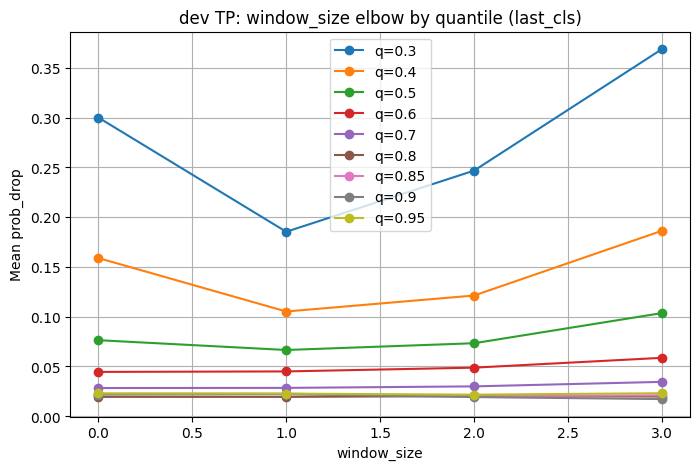

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_window_elbow_by_quantile_last_cls.png


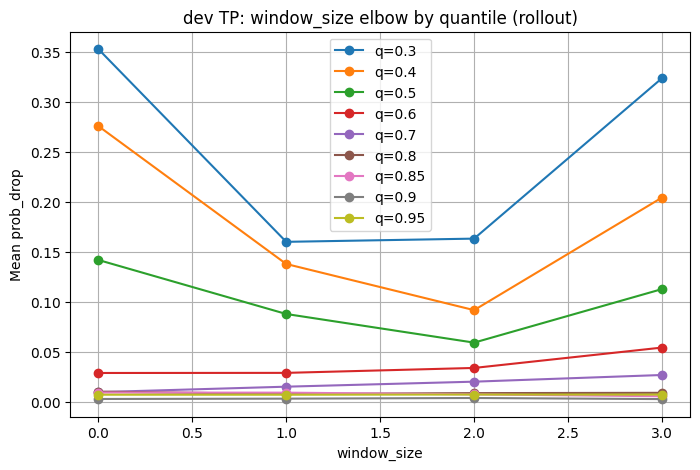

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_window_elbow_by_quantile_rollout.png


In [13]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 5))
    
    for quantile in sorted(method_df["quantile"].unique()):
        subset = method_df[
            method_df["quantile"] == quantile
        ].sort_values("window_size")
        
        plt.plot(
            subset["window_size"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"q={quantile}"
        )
    
    plt.xlabel("window_size")
    plt.ylabel("Mean prob_drop")
    plt.title(f"dev TP: window_size elbow by quantile ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_window_elbow_by_quantile_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

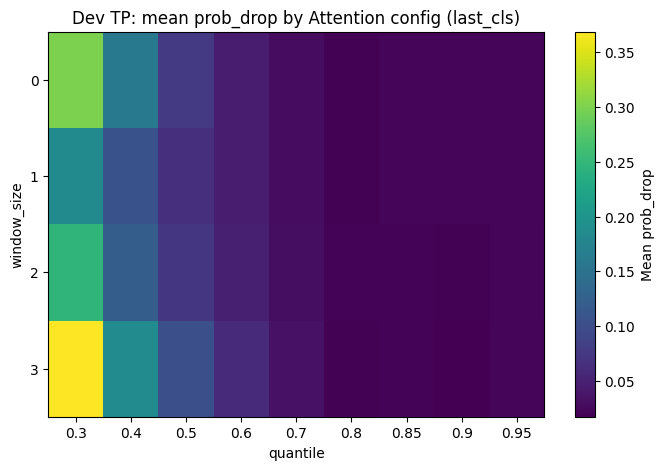

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_find_config_heatmap_last_cls.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.300059,0.158925,0.076413,0.044555,0.028352,0.019479,0.022702,0.021795,0.022877
1,0.185330,0.105224,0.066571,0.045046,0.028512,0.019460,0.022629,0.022111,0.022755
2,0.246752,0.121283,0.073360,0.048835,0.030020,0.020259,0.020068,0.019277,0.021712
3,0.368818,0.186337,0.103646,0.058703,0.034556,0.019836,0.021095,0.017260,0.023132


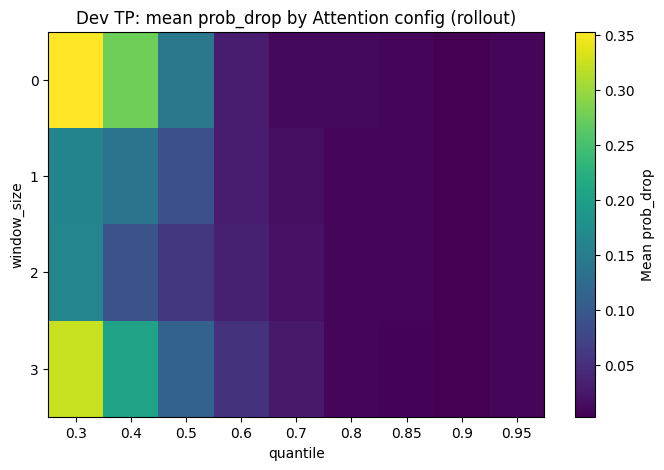

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_find_config_heatmap_rollout.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.353040,0.275989,0.141964,0.028847,0.009674,0.010181,0.009259,0.002818,0.007105
1,0.160112,0.137939,0.087888,0.028955,0.015130,0.007818,0.009159,0.003161,0.007086
2,0.163327,0.091743,0.059226,0.033885,0.020147,0.008696,0.007426,0.003812,0.007276
3,0.323901,0.204417,0.112808,0.054272,0.026829,0.008989,0.005543,0.002721,0.007224


In [14]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    heatmap_data = method_df.pivot(
        index="window_size",
        columns="quantile",
        values="mean_prob_drop"
    )
    
    plt.figure(figsize=(8, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label="Mean prob_drop")
    
    plt.xticks(
        ticks=np.arange(len(heatmap_data.columns)),
        labels=heatmap_data.columns
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index
    )
    
    plt.xlabel("quantile")
    plt.ylabel("window_size")
    plt.title(f"Dev TP: mean prob_drop by Attention config ({method})")
    
    plot_path = dev_output_dir / f"attention_dev_find_config_heatmap_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)
    display(heatmap_data)

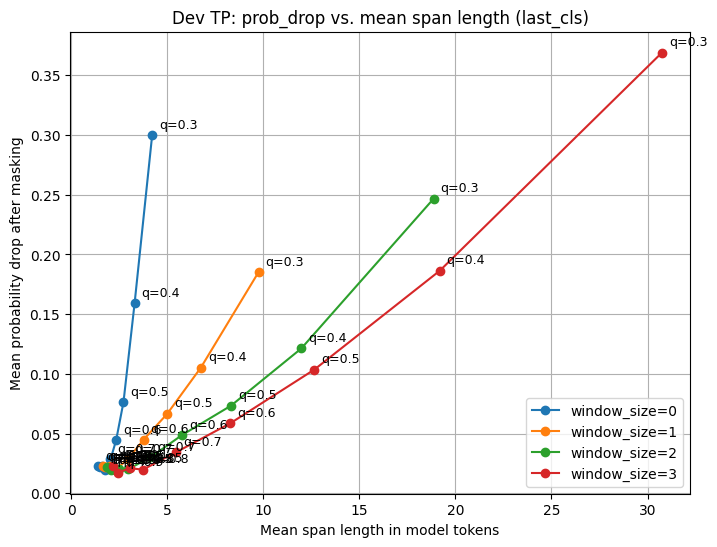

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_prob_drop_vs_mean_span_len_last_cls.png


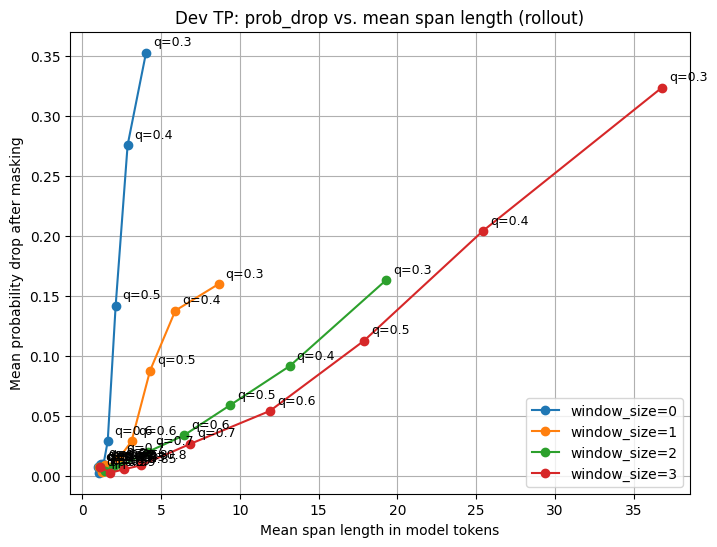

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_prob_drop_vs_mean_span_len_rollout.png


In [15]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_span_len_tokens"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_span_len_tokens"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean span length in model tokens")
    plt.ylabel("Mean probability drop after masking")
    plt.title(f"Dev TP: prob_drop vs. mean span length ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_prob_drop_vs_mean_span_len_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

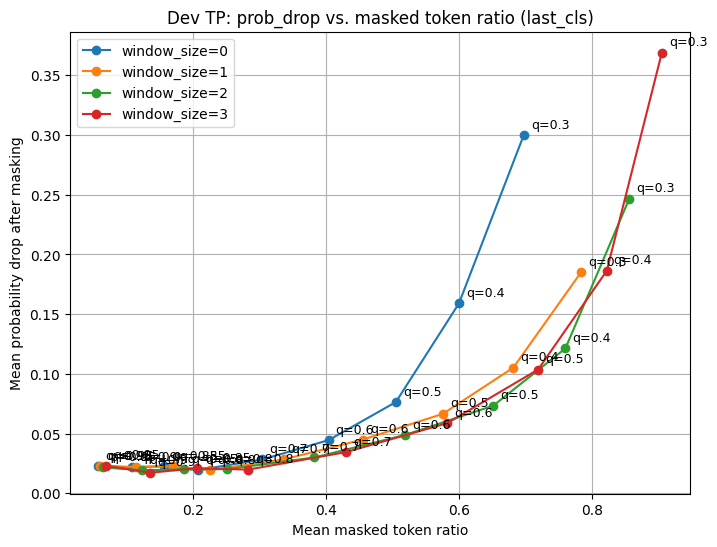

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_last_cls.png


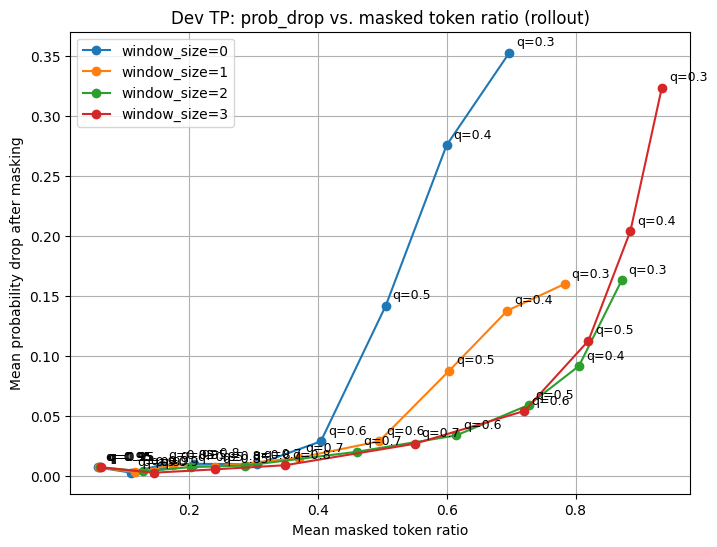

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_rollout.png


In [16]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Mean probability drop after masking")
    plt.title(f"Dev TP: prob_drop vs. masked token ratio ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_prob_drop_vs_masked_token_ratio_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

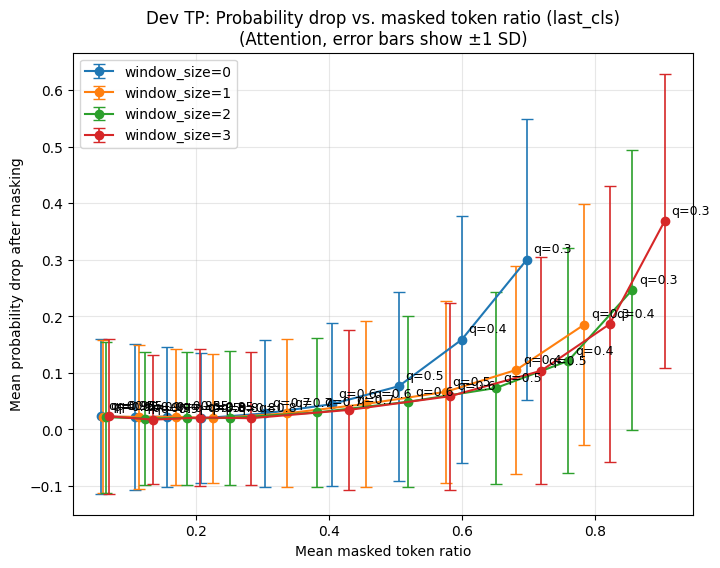

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_with_std_last_cls.png


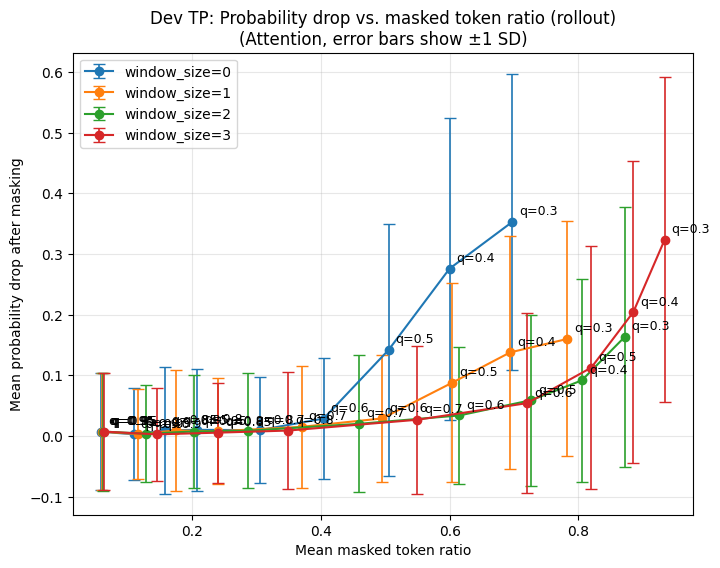

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_with_std_rollout.png


In [17]:
for method in sorted(dev_config_summary["attention_method"].unique()):

    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
    
        plt.errorbar(
            subset["mean_masked_token_ratio"],
            subset["mean_prob_drop"],
            yerr=subset["std_prob_drop"],
            marker="o",
            linestyle="-",
            capsize=4,
            elinewidth=1.2,
            label=f"window_size={window_size}"
        )
    
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (
                    row["mean_masked_token_ratio"],
                    row["mean_prob_drop"]
                ),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Mean probability drop after masking")
    plt.title(
        f"Dev TP: Probability drop vs. masked token ratio ({method})\n"
        "(Attention, error bars show ±1 SD)"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plot_path = (
        dev_output_dir
        / f"attention_dev_prob_drop_vs_masked_token_ratio_with_std_{method}.png"
    )
    
    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    
    print("Saved plot:", plot_path)

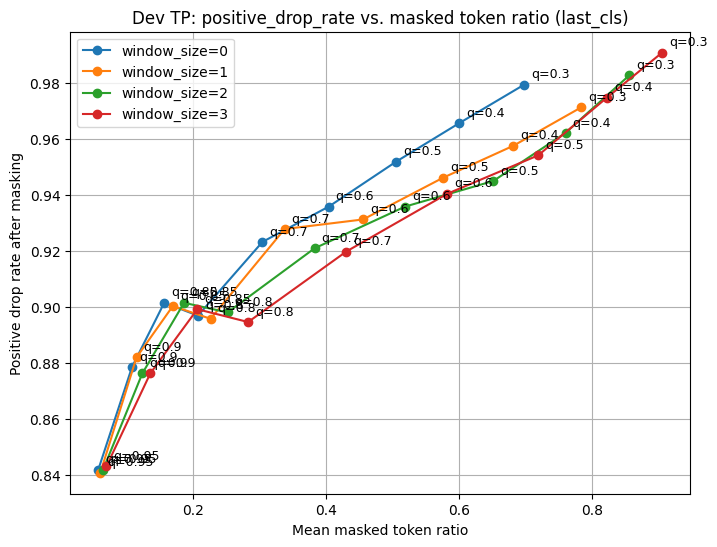

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_positive_drop_rate_vs_masked_token_ratio_last_cls.png


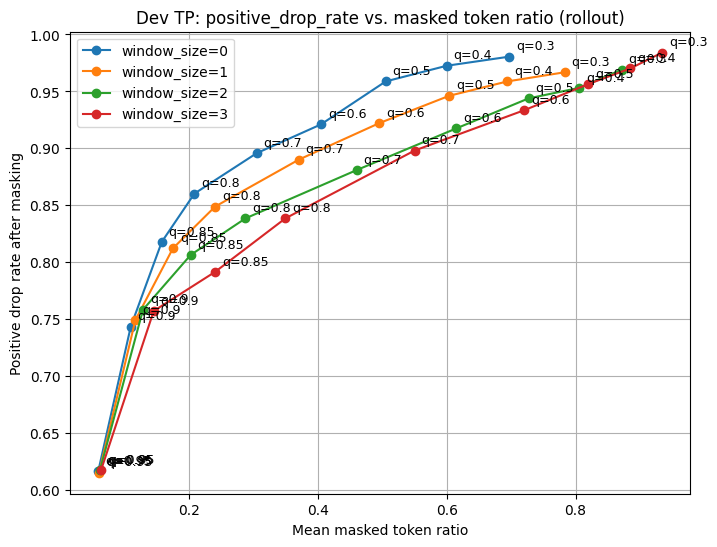

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/dev_config_selection/attention_dev_positive_drop_rate_vs_masked_token_ratio_rollout.png


In [18]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["positive_drop_rate"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_masked_token_ratio"], row["positive_drop_rate"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Positive drop rate after masking")
    plt.title(f"Dev TP: positive_drop_rate vs. masked token ratio ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_positive_drop_rate_vs_masked_token_ratio_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

In [54]:
# Provisional config from raw attention validation results.
# This is not the final config yet.
# It is only used for qualitative inspection before word-boundary post-processing.

BEST_ATTENTION_METHOD = "rollout"
BEST_QUANTILE = 0.4
BEST_WINDOW_SIZE = 0

selected_config_summary_raw = dev_config_summary[
    (dev_config_summary["attention_method"] == BEST_ATTENTION_METHOD) &
    (dev_config_summary["quantile"] == BEST_QUANTILE) &
    (dev_config_summary["window_size"] == BEST_WINDOW_SIZE)
]

display(selected_config_summary_raw)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,median_masked_token_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_attention,mean_span_score_mean_attention,prob_drop_per_masked_token,prob_drop_per_masked_ratio
37,rollout,0,0.4,873,0.275989,0.220642,0.249155,0.972509,0.867125,0.691867,...,0.6,16826,2.880423,2.0,10.162427,6.0,0.041818,0.014692,0.004971,0.460205


## Provisionally selected attention configuration

The attention-based method was tuned on validation true positives, i.e., arguments that were labeled as inappropriate and also predicted as inappropriate by the document-level classifier. This keeps the configuration selection comparable to the other span localization methods.

The evaluated configurations varied:

- `attention_method ∈ {last_cls, rollout}`
- `quantile ∈ {0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95}`
- `window_size ∈ {0, 1, 2, 3}`

In this notebook, `window_size` is a merge-gap parameter for attention-based spans. It does not add a symmetric token window around selected tokens. Instead, it controls how many unselected tokens may lie between selected tokens for them to be merged into one span.

The final configuration was selected based on the validation trade-off between probability drop and masked token ratio. The selected setting is:

- `attention_method = last_cls`
- `quantile = 0.95`
- `window_size = 1`

This setting produces very short spans while still yielding a positive average probability drop after masking. However, because attention weights are not guaranteed to be faithful explanations, the method is interpreted as a candidate-generation approach validated through perturbation.

In [32]:
def show_attention_example(result_df, index=0):
    """Display one attention result with highlighted masked spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["merged_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>method:</b> {html.escape(str(row["attention_method"]))} |
        <b>quantile:</b> {row["quantile"]} |
        <b>window_size:</b> {row["window_size"]}<br>
        <b>merged_spans:</b> {html.escape(str(row["merged_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_masked:</b> {float(row["p_inappropriate_masked"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <hr>
        <p>{marked}</p>
    </div>
    """))

## Qualitative inspection of the provisional raw-attention configuration

Before applying the selected attention configuration to the full dataset, the extracted validation examples are inspected qualitatively.

This step is important because the quantitative validation results may still favor configurations that produce tokenizer artifacts rather than interpretable evidence spans. In particular, attention-based extraction operates on model tokens and may therefore highlight:

- subword fragments such as `'t` from `don't`
- punctuation-only spans such as `"`, `.`, or `."`

If such artifacts occur frequently, the raw attention extraction is not sufficiently interpretable, even if the masking-based probability drop is high. In that case, a word-boundary post-processing step is introduced and the validation-based hyperparameter search is repeated using the post-processed spans.

In [55]:
dev_raw_best_examples = dev_tp_argument_df[
    (dev_tp_argument_df["attention_method"] == BEST_ATTENTION_METHOD) &
    (dev_tp_argument_df["quantile"] == BEST_QUANTILE) &
    (dev_tp_argument_df["window_size"] == BEST_WINDOW_SIZE) &
    (dev_tp_argument_df["error"].isna())
].copy()

print("Dev examples for provisional raw config:", len(dev_raw_best_examples))
display(
    dev_raw_best_examples[
        [
            "global_row_id",
            "post_id",
            "prob_drop",
            "masked_token_ratio",
            "merged_span_texts"
        ]
    ].head()
)

Dev examples for provisional raw config: 873


,global_row_id,post_id,prob_drop,masked_token_ratio,merged_span_texts
40,0,1,0.029803,0.595238,"[people cant be forced to wear, uniforms, i, h..."
112,1,2,0.612050,0.600000,"[That form of, degrades this forum, and will, ..."
184,3,4,0.012809,0.593750,"[No I wouldn', in my spouse., the girl that i,..."
256,4,5,0.014057,0.594595,"[TV is, . Except for, . That's an alright, ., ..."
328,5,6,0.013503,0.600000,"[I love, , I, in them. They also, your literat..."


In [34]:
tmp_raw_top = (
    dev_raw_best_examples
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_raw_top))):
    show_attention_example(tmp_raw_top, index=i)

# Summary and saving results without word boundary

In [57]:
def run_final_attention_on_split(df, split_name):
    """
    Run the selected Attention configuration on one split.
    
    The final configuration is fixed and not re-tuned per split.
    """
    positions = list(range(len(df)))
    
    raw_results = run_attention_config_on_indices(
        df=df,
        matrix_positions=positions,
        attention_methods=[BEST_ATTENTION_METHOD],
        quantile_values=[BEST_QUANTILE],
        window_size_values=[BEST_WINDOW_SIZE],
        mask_token=MASK_TOKEN
    )
    
    argument_df = build_argument_level_df(raw_results)
    span_df = build_span_level_df(raw_results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return raw_results, argument_df, span_df


# train_results, train_argument_df, train_span_df = run_final_attention_on_split(
#     train_df,
#     "train"
# )

# val_results, val_argument_df, val_span_df = run_final_attention_on_split(
#     val_df,
#     "validation"
# )

test_results, test_argument_df, test_span_df = run_final_attention_on_split(
    test_df,
    "test"
)

Building attention spans:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

test argument level: (438, 43)
test span level: (8859, 36)


In [58]:
final_argument_df = pd.concat(
    [test_argument_df],
    ignore_index=True
)

final_span_df = pd.concat(
    [test_span_df],
    ignore_index=True
)

display(final_argument_df.head())
display(final_span_df.head())

print("Final argument-level rows:", len(final_argument_df))
print("Final span-level rows:", len(final_span_df))

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,0.892727,FN,False,True,...,"[students should, they, and feel, their clothes]","[1, 5, 7, 11]","[2, 5, 8, 12]","[0, 26, 36, 56]","[15, 30, 44, 69]","[""▁students"", ""▁should"", ""▁they"", ""▁and"", ""▁fe...","[{""char_start"": 0, ""char_end"": 15, ""token_star...",students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...,None
1,1754,test,8,Tv is better than books:,1,LABEL_1,0.997475,TP,True,False,...,"[I thick that book are, is it is, i, you in a,...","[1, 9, 13, 16, 24]","[5, 11, 13, 18, 27]","[0, 37, 53, 63, 91]","[21, 45, 54, 71, 112]","[""▁I"", ""▁thick"", ""▁that"", ""▁book"", ""▁are"", ""▁i...","[{""char_start"": 0, ""char_end"": 21, ""token_star...",I thick that book are better than TV is it is ...,[MASK] [MASK] [MASK] [MASK] [MASK] better than...,None
2,1755,test,9,Tv is better than books:,1,LABEL_1,0.998255,TP,True,False,...,"[Books enlighten the soul. Books, ', the moral...","[1, 8, 11, 15, 18, 21, 25, 28, 33, 35, 38, 41,...","[6, 8, 13, 15, 18, 23, 26, 30, 33, 36, 38, 42,...","[0, 35, 46, 68, 82, 96, 117, 129, 159, 169, 18...","[31, 36, 59, 69, 85, 107, 123, 143, 160, 174, ...","[""▁Books"", ""▁enlighten"", ""▁the"", ""▁soul"", ""."",...","[{""char_start"": 0, ""char_end"": 31, ""token_star...",Books enlighten the soul. Books don't destroy ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] don[...,None
3,1756,test,12,India has the potential to lead the world:,1,LABEL_1,0.995627,TP,True,False,...,"[india is is, but a, and, should be a, developer]","[1, 6, 10, 12, 16]","[3, 7, 10, 14, 16]","[0, 25, 45, 56, 74]","[11, 30, 48, 67, 83]","[""▁india"", ""▁is"", ""▁is"", ""▁but"", ""▁a"", ""▁and"",...","[{""char_start"": 0, ""char_end"": 11, ""token_star...",india is is good adopter but a bad developer a...,[MASK] [MASK] [MASK] good adopter [MASK] [MASK...,None
4,1757,test,15,Is it better to have a lousy father or to be f...,0,LABEL_0,0.993661,TN,False,False,...,"[Honestly, I'd, be, ,, that, is, , albeit a lo...","[1, 7, 11, 14, 17, 22, 27, 33, 41, 48, 50, 55,...","[5, 7, 11, 14, 17, 25, 30, 35, 41, 48, 53, 58,...","[0, 21, 45, 58, 74, 99, 119, 143, 186, 224, 23...","[13, 23, 46, 62, 76, 115, 131, 155, 189, 227, ...","[""▁Honestly"", "","", ""▁I"", ""'"", ""d"", ""▁be"", "","",...","[{""char_start"": 0, ""char_end"": 13, ""token_star...","Honestly, I'd rather be completely fatherless,...",[MASK] [MASK] [MASK] [MASK] [MASK] rather [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.105267,0.107273,0.910976,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
1,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.084161,0.107273,0.910976,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
2,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.134787,0.107273,0.910976,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
3,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.125380,0.107273,0.910976,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
4,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,0.044088,0.997475,0.972825,0.024650,27,16,0.592593,0.592593,I thick that book are better than TV is it is ...,[MASK] [MASK] [MASK] [MASK] [MASK] better than...


Final argument-level rows: 438
Final span-level rows: 8859


In [59]:
final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

overall_summary = (
    final_argument_df_valid
    .groupby(["split", "attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

confusion_summary = (
    final_argument_df_valid
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

display(overall_summary)
display(confusion_summary)

,split,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,rollout,0,0.4,438,-0.06905,0.009295,0.447061,0.563927,0.495434,0.378995,0.590803,0.659853,20.226027,57.97032,0.599908


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,FN,39,-0.502263,-0.425042,0.216772,0.000000,0.049637,0.551900,22.743590,65.358974,0.599475
1,test,FP,71,0.270096,0.158197,0.263900,0.929577,0.971583,0.701487,18.154930,51.408451,0.600268
2,test,TN,142,-0.520973,-0.432638,0.225374,0.014085,0.037214,0.558187,22.894366,65.957746,0.599689
3,test,TP,186,0.237342,0.134223,0.250078,0.962366,0.981553,0.744211,18.451613,52.827957,0.600029


In [60]:
test_argument_df_valid = test_argument_df[
    test_argument_df["error"].isna()
].copy()

test_overall_summary = (
    test_argument_df_valid
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

test_confusion_summary = (
    test_argument_df_valid
    .groupby("confusion_type")
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values("confusion_type")
)

display(test_overall_summary)
display(test_confusion_summary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,rollout,0,0.4,438,-0.06905,0.009295,0.447061,0.563927,0.495434,0.378995,0.590803,0.659853,20.226027,57.97032,0.599908


,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,FN,39,-0.502263,-0.425042,0.216772,0.000000,0.049637,0.551900,22.743590,65.358974,0.599475
1,FP,71,0.270096,0.158197,0.263900,0.929577,0.971583,0.701487,18.154930,51.408451,0.600268
2,TN,142,-0.520973,-0.432638,0.225374,0.014085,0.037214,0.558187,22.894366,65.957746,0.599689
3,TP,186,0.237342,0.134223,0.250078,0.962366,0.981553,0.744211,18.451613,52.827957,0.600029


In [61]:
final_output_dir = OUTPUT_DIR / "attention_results_final" 
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_span_level.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"attention_final_test_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_summary.csv"
)

jsonl_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.jsonl"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_overall_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

all_results = test_results

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in all_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)
print(jsonl_path)

Saved:
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_argument_level.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_span_level.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_overall_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_confusion_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_final/attention_final_test_rollout_q0.4_window0_summary.csv
/Users/karsten/Workspace/Locali

In [62]:
# Best test examples by probability drop
tmp = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp))):
    show_attention_example(tmp, index=i)

In [63]:
# Test examples with the smallest or negative probability drops
tmp_low = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_low))):
    show_attention_example(tmp_low, index=i)

## Re-tuning after Word-boundary post-processing

The attention-based extraction operates on model tokens, not on linguistic words. Since transformer tokenizers often split words into subword units and punctuation tokens, extracted spans may contain only fragments such as `'t` from `can't` or punctuation-only spans such as `"`, `.`, or `."`.

This is problematic for span localization because the goal of this thesis is not to identify tokenizer artifacts, but interpretable text spans that can be read as meaningful evidence for the model prediction.

To reduce such artifacts, this section adds a word-boundary post-processing step after attention-based span extraction:

1. If an extracted span overlaps with a word, the span is expanded to cover the full word.
2. For example, a selected fragment such as `'t` in `don't` is expanded to the full word `can't`.
3. Spans that consist only of punctuation and do not overlap with any word are removed.
4. After expansion, overlapping spans are merged.
5. The resulting word-boundary spans are masked again and the probability drop is recomputed.

This does not change how attention scores are computed. It only changes how token-level attention candidates are converted into readable character spans. Therefore, this step should be interpreted as a post-processing improvement for human interpretability, not as a new attribution method.

In [35]:
# Output folder for word-boundary post-processing results
WORD_BOUNDARY_OUTPUT_DIR = OUTPUT_DIR / "attention_results_word_boundary"
WORD_BOUNDARY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Whether punctuation-only spans should be removed.
# This is important because punctuation often receives high attention but is rarely interpretable as evidence by itself.
DROP_PUNCTUATION_ONLY_SPANS = True

print("Word-boundary output directory:", WORD_BOUNDARY_OUTPUT_DIR)

Word-boundary output directory: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary


### Fallback for punctuation-only spans

The word-boundary post-processing removes punctuation-only spans because they are often tokenizer artifacts and are usually difficult to interpret as meaningful evidence.

However, removing all punctuation-only spans can also be too strict. In some arguments, the raw attention extraction may select only punctuation tokens. If all of these are removed, the resulting span list becomes empty, no text is masked, and the probability drop is necessarily zero. This would make the result less informative, because the original attention method did identify model-relevant tokens.

Therefore, this notebook uses a conservative fallback rule:

- If word-boundary post-processing produces at least one span, the post-processed spans are used.
- If word-boundary post-processing removes all spans, the original raw attention spans are kept.
- A boolean flag `word_boundary_fallback_used` records whether this fallback was applied.

This keeps the method interpretable where possible, while avoiding empty span outputs when the raw attention method selected only punctuation.

In [36]:
def get_word_spans(text):
    """
    Return word-like character spans in text.
    
    This pattern keeps common contractions and hyphenated words together:
    - can't
    - don't
    - day-to-day
    """
    text = str(text)
    pattern = re.compile(r"\b\w+(?:['’\-]\w+)*\b", flags=re.UNICODE)
    
    return [
        {
            "char_start": int(match.start()),
            "char_end": int(match.end()),
            "word": match.group(0)
        }
        for match in pattern.finditer(text)
    ]


def get_token_offsets_for_text(text):
    """
    Tokenize text and return valid model-token offsets.
    
    This is used only for updating token-level metadata after word-boundary expansion.
    """
    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        return_offsets_mapping=True,
        return_special_tokens_mask=True,
        return_tensors="pt"
    )
    
    offsets = enc["offset_mapping"][0].tolist()
    special_mask = enc["special_tokens_mask"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
    
    valid_token_rows = []
    
    for idx, ((start, end), is_special) in enumerate(zip(offsets, special_mask)):
        if is_special == 0 and end > start:
            valid_token_rows.append({
                "token_idx": int(idx),
                "token": tokens[idx],
                "char_start": int(start),
                "char_end": int(end)
            })
    
    return valid_token_rows

def expand_span_to_word_boundary(span, word_spans):
    """
    Expand one extracted span to full word boundaries.
    
    If the span overlaps one or more words, the returned character span covers
    the full overlapping word(s). If the span overlaps no word, None is returned.
    """
    span_start = int(span["char_start"])
    span_end = int(span["char_end"])
    
    overlapping_words = [
        word
        for word in word_spans
        if word["char_start"] < span_end and word["char_end"] > span_start
    ]
    
    if not overlapping_words:
        return None
    
    new_start = min(word["char_start"] for word in overlapping_words)
    new_end = max(word["char_end"] for word in overlapping_words)
    
    expanded_span = dict(span)
    expanded_span["char_start"] = int(new_start)
    expanded_span["char_end"] = int(new_end)
    expanded_span["span_text"] = None
    expanded_span["span_len_chars"] = int(new_end - new_start)
    expanded_span["word_boundary_expanded"] = True
    
    return expanded_span


def merge_overlapping_boundary_spans(spans, text):
    """
    Merge spans that overlap after word-boundary expansion.
    """
    if not spans:
        return []
    
    spans = sorted(spans, key=lambda x: (x["char_start"], x["char_end"]))
    merged = []
    
    current = dict(spans[0])
    
    for span in spans[1:]:
        if span["char_start"] <= current["char_end"]:
            current["char_end"] = max(current["char_end"], span["char_end"])
            current["span_len_chars"] = current["char_end"] - current["char_start"]
            
            current["selected_token_indices"] = sorted(
                set(current.get("selected_token_indices", []))
                | set(span.get("selected_token_indices", []))
            )
            
            current["selected_token_texts"] = (
                current.get("selected_token_texts", [])
                + span.get("selected_token_texts", [])
            )
            
            current["span_score_sum_attention"] = float(
                current.get("span_score_sum_attention", 0.0)
                + span.get("span_score_sum_attention", 0.0)
            )
            
            current["span_score_max_attention"] = max(
                float(current.get("span_score_max_attention", 0.0)),
                float(span.get("span_score_max_attention", 0.0))
            )
        else:
            merged.append(current)
            current = dict(span)
    
    merged.append(current)
    
    for idx, span in enumerate(merged):
        span["span_idx"] = int(idx)
        span["span_text"] = text[span["char_start"]:span["char_end"]]
        span["span_len_chars"] = int(span["char_end"] - span["char_start"])
        
        if len(span.get("selected_token_indices", [])) > 0:
            span["span_score_mean_attention"] = float(
                span["span_score_sum_attention"] / len(span["selected_token_indices"])
            )
        else:
            span["span_score_mean_attention"] = 0.0
    
    return merged

def update_span_token_metadata(spans, text):
    """
    Update token start/end indices and token lengths after character spans were expanded.
    """
    if not spans:
        return []
    
    token_rows = get_token_offsets_for_text(text)
    updated_spans = []
    
    for span in spans:
        span = dict(span)
        start = int(span["char_start"])
        end = int(span["char_end"])
        
        overlapping_tokens = [
            token
            for token in token_rows
            if token["char_start"] < end and token["char_end"] > start
        ]
        
        if overlapping_tokens:
            token_start_idx = min(token["token_idx"] for token in overlapping_tokens)
            token_end_idx = max(token["token_idx"] for token in overlapping_tokens)
            span_len_tokens = token_end_idx - token_start_idx + 1
        else:
            token_start_idx = span.get("token_start_idx", None)
            token_end_idx = span.get("token_end_idx", None)
            span_len_tokens = span.get("span_len_tokens", 0)
        
        span["token_start_idx"] = int(token_start_idx) if token_start_idx is not None else None
        span["token_end_idx"] = int(token_end_idx) if token_end_idx is not None else None
        span["span_len_tokens"] = int(span_len_tokens)
        
        updated_spans.append(span)
    
    return updated_spans


def apply_word_boundary_to_spans(text, merged_spans, drop_punctuation_only=True):
    """
    Apply word-boundary post-processing to extracted attention spans.
    
    Punctuation-only spans are removed if they do not overlap with a word.
    Subword fragments are expanded to the full word they belong to.
    """
    text = str(text)
    word_spans = get_word_spans(text)
    
    boundary_spans = []
    
    for span in merged_spans:
        expanded = expand_span_to_word_boundary(span, word_spans)
        
        if expanded is None:
            if drop_punctuation_only:
                continue
            
            copied = dict(span)
            copied["word_boundary_expanded"] = False
            boundary_spans.append(copied)
        else:
            expanded["span_text"] = text[expanded["char_start"]:expanded["char_end"]]
            boundary_spans.append(expanded)
    
    boundary_spans = merge_overlapping_boundary_spans(boundary_spans, text)
    boundary_spans = update_span_token_metadata(boundary_spans, text)
    
    return boundary_spans

In [37]:
def apply_word_boundary_to_argument_results(argument_results):
    """
    Apply word-boundary post-processing to already extracted attention results,
    then recompute masked text and probability drop.
    
    Fallback rule:
    If word-boundary post-processing removes all spans, keep the original raw
    attention spans instead of returning an empty span list.
    """
    updated_results = []
    masked_texts_to_score = []
    masked_lookup = []
    
    for result in tqdm(argument_results, desc="Applying word-boundary post-processing"):
        updated = dict(result)
        text = str(updated["text"])
        
        original_spans = updated.get("merged_spans", [])
        
        boundary_spans_before_fallback = apply_word_boundary_to_spans(
            text=text,
            merged_spans=original_spans,
            drop_punctuation_only=DROP_PUNCTUATION_ONLY_SPANS
        )
        
        word_boundary_fallback_used = False
        boundary_spans = boundary_spans_before_fallback
        
        # Fallback: do not allow word-boundary post-processing to remove all spans.
        # If all spans would be removed, keep the original raw attention spans.
        if len(boundary_spans_before_fallback) == 0 and len(original_spans) > 0:
            boundary_spans = original_spans
            word_boundary_fallback_used = True
        
        masked_text = mask_spans_in_text(
            text=text,
            spans=boundary_spans,
            mask_token=MASK_TOKEN
        )
        
        total_masked_tokens = sum(
            span.get("span_len_tokens", 0)
            for span in boundary_spans
        )
        
        total_masked_chars = sum(
            span.get("span_len_chars", 0)
            for span in boundary_spans
        )
        
        n_model_tokens = int(updated.get("n_model_tokens", 0))
        masked_token_ratio = (
            total_masked_tokens / n_model_tokens
            if n_model_tokens > 0
            else 0.0
        )
        
        updated["merged_spans_original_attention"] = original_spans
        updated["merged_spans"] = boundary_spans
        updated["masked_text"] = masked_text
        
        updated["n_merged_spans_original_attention"] = int(len(original_spans))
        updated["n_merged_spans_word_boundary_before_fallback"] = int(
            len(boundary_spans_before_fallback)
        )
        updated["word_boundary_fallback_used"] = bool(word_boundary_fallback_used)
        
        updated["n_merged_spans"] = int(len(boundary_spans))
        updated["total_masked_tokens"] = int(total_masked_tokens)
        updated["total_masked_chars"] = int(total_masked_chars)
        updated["masked_token_ratio"] = float(masked_token_ratio)
        
        updated["word_boundary_postprocessed"] = True
        updated["drop_punctuation_only_spans"] = bool(DROP_PUNCTUATION_ONLY_SPANS)
        
        updated_results.append(updated)
        masked_lookup.append(len(updated_results) - 1)
        masked_texts_to_score.append(masked_text)
    
    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            texts=masked_texts_to_score,
            classifier=pipe,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = updated_results[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            
            result["p_inappropriate_masked"] = p_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
    
    return updated_results

In [38]:
dev_tp_results_word_boundary = apply_word_boundary_to_argument_results(dev_tp_results)

dev_tp_argument_df_word_boundary = build_argument_level_df(dev_tp_results_word_boundary)
dev_tp_span_df_word_boundary = build_span_level_df(dev_tp_results_word_boundary)

display(dev_tp_argument_df_word_boundary.head())
display(dev_tp_span_df_word_boundary.head())

Applying word-boundary post-processing:   0%|          | 0/62856 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/3929 [00:00<?, ?it/s]

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27, 40]","[15, 21, 37, 41]","[0, 93, 119, 191]","[69, 97, 179, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27, 40]","[15, 21, 37, 41]","[0, 93, 119, 191]","[69, 97, 179, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27]","[15, 21, 41]","[0, 93, 119]","[69, 97, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27]","[15, 21, 41]","[0, 93, 119]","[69, 97, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 15, 21, 27, 36, 41]","[13, 15, 21, 34, 36, 41]","[0, 66, 93, 119, 167, 201]","[58, 69, 97, 156, 173, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 58, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.909959,0.087073,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.018986,0.997032,0.909959,0.087073,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.056030,0.997032,0.909959,0.087073,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.017655,0.997032,0.909959,0.087073,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.909959,0.087073,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...


In [39]:
dev_tp_argument_df_word_boundary_valid = dev_tp_argument_df_word_boundary[
    dev_tp_argument_df_word_boundary["error"].isna()
].copy()

dev_config_summary_word_boundary = (
    dev_tp_argument_df_word_boundary_valid
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_n_selected_tokens=("n_selected_tokens", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        median_total_masked_tokens=("total_masked_tokens", "median"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_selected_token_ratio=("selected_token_ratio", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

span_len_summary_word_boundary = (
    dev_tp_span_df_word_boundary
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_spans=("span_text", "count"),
        mean_span_len_tokens=("span_len_tokens", "mean"),
        median_span_len_tokens=("span_len_tokens", "median"),
        mean_span_len_chars=("span_len_chars", "mean"),
        median_span_len_chars=("span_len_chars", "median"),
        mean_span_score_sum_attention=("span_score_sum_attention", "mean"),
        mean_span_score_mean_attention=("span_score_mean_attention", "mean"),
    )
    .reset_index()
)

dev_config_summary_word_boundary = dev_config_summary_word_boundary.merge(
    span_len_summary_word_boundary,
    on=["attention_method", "window_size", "quantile"],
    how="left"
)

dev_config_summary_word_boundary["prob_drop_per_masked_token"] = (
    dev_config_summary_word_boundary["mean_prob_drop"] /
    dev_config_summary_word_boundary["mean_total_masked_tokens"].replace(0, np.nan)
)

dev_config_summary_word_boundary["prob_drop_per_masked_ratio"] = (
    dev_config_summary_word_boundary["mean_prob_drop"] /
    dev_config_summary_word_boundary["mean_masked_token_ratio"].replace(0, np.nan)
)

dev_config_summary_word_boundary = dev_config_summary_word_boundary.sort_values(
    ["attention_method", "window_size", "quantile"]
)

display(dev_config_summary_word_boundary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,mean_masked_token_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_attention,mean_span_score_mean_attention,prob_drop_per_masked_token,prob_drop_per_masked_ratio
0,last_cls,0,0.30,873,0.096135,0.012011,0.194212,0.947308,0.536082,0.295533,...,0.653482,12053,4.391604,2.0,18.721729,9.0,0.061652,0.011402,0.001586,0.147111
1,last_cls,0,0.40,873,0.050717,0.004405,0.157775,0.931271,0.323024,0.147766,...,0.551774,12894,3.454165,2.0,14.189623,7.0,0.053386,0.012498,0.000994,0.091916
2,last_cls,0,0.50,873,0.034600,0.002502,0.146845,0.908362,0.190149,0.088202,...,0.455232,12614,2.896544,1.0,11.410021,5.0,0.049725,0.013915,0.000827,0.076005
3,last_cls,0,0.60,873,0.026586,0.001709,0.139552,0.876289,0.119129,0.061856,...,0.355161,11220,2.542692,1.0,9.499554,4.0,0.049346,0.016053,0.000814,0.074857
4,last_cls,0,0.70,873,0.017343,0.001213,0.114725,0.861397,0.077892,0.046964,...,0.258926,9021,2.313158,1.0,8.197428,4.0,0.051637,0.019303,0.000726,0.066982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,rollout,3,0.70,873,0.018609,0.000922,0.118728,0.836197,0.100802,0.054983,...,0.491712,5619,7.190603,5.0,30.507742,21.0,0.081620,0.020708,0.000402,0.037845
68,rollout,3,0.80,873,0.005515,0.000388,0.092845,0.741123,0.040092,0.022910,...,0.276891,5420,4.138930,3.0,17.094649,12.0,0.058355,0.022603,0.000215,0.019916
69,rollout,3,0.85,873,0.003143,0.000171,0.084834,0.664376,0.028637,0.017182,...,0.162974,4327,3.020800,2.0,12.170095,8.0,0.051629,0.024624,0.000210,0.019285
70,rollout,3,0.90,873,0.000400,0.000030,0.071499,0.544101,0.020619,0.011455,...,0.079127,2653,2.093856,1.0,7.733886,3.0,0.053144,0.032951,0.000063,0.005056


In [40]:
dev_tp_argument_df_word_boundary.to_csv(
    WORD_BOUNDARY_OUTPUT_DIR / "attention_dev_tp_argument_level_word_boundary.csv",
    index=False,
    encoding="utf-8"
)

dev_tp_span_df_word_boundary.to_csv(
    WORD_BOUNDARY_OUTPUT_DIR / "attention_dev_tp_span_level_word_boundary.csv",
    index=False,
    encoding="utf-8"
)

dev_config_summary_word_boundary.to_csv(
    WORD_BOUNDARY_OUTPUT_DIR / "attention_dev_config_summary_word_boundary.csv",
    index=False,
    encoding="utf-8"
)

print("Saved validation word-boundary files to:", WORD_BOUNDARY_OUTPUT_DIR)

Saved validation word-boundary files to: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary


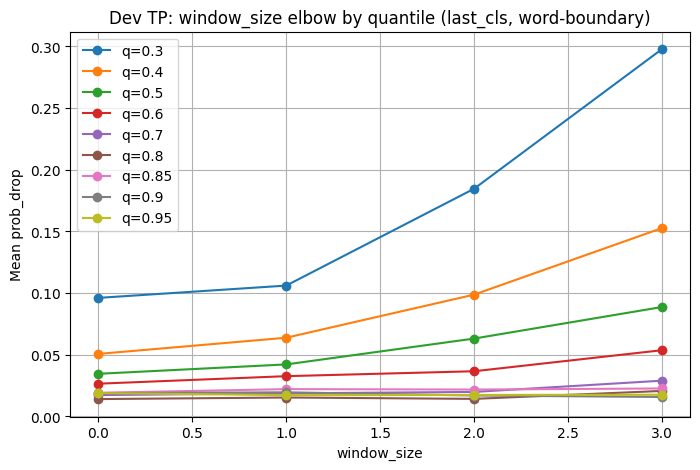

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_dev_window_elbow_by_quantile_last_cls_word_boundary.png


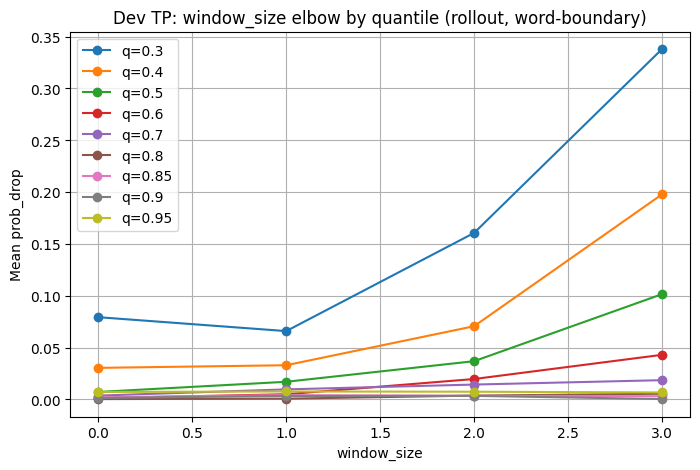

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_dev_window_elbow_by_quantile_rollout_word_boundary.png


In [41]:
for method in sorted(dev_config_summary_word_boundary["attention_method"].unique()):
    method_df = dev_config_summary_word_boundary[
        dev_config_summary_word_boundary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 5))
    
    for quantile in sorted(method_df["quantile"].unique()):
        subset = method_df[
            method_df["quantile"] == quantile
        ].sort_values("window_size")
        
        plt.plot(
            subset["window_size"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"q={quantile}"
        )
    
    plt.xlabel("window_size")
    plt.ylabel("Mean prob_drop")
    plt.title(f"Dev TP: window_size elbow by quantile ({method}, word-boundary)")
    plt.grid(True)
    plt.legend()
    
    plot_path = WORD_BOUNDARY_OUTPUT_DIR / f"attention_dev_window_elbow_by_quantile_{method}_word_boundary.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

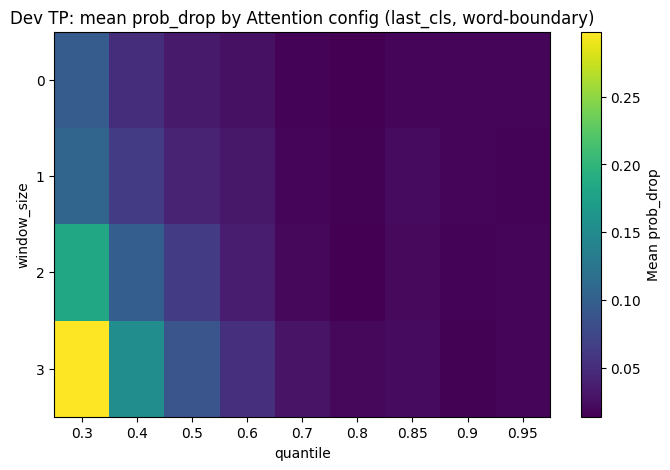

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_dev_find_config_heatmap_last_cls_word_boundary.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.096135,0.050717,0.034600,0.026586,0.017343,0.014109,0.019233,0.018876,0.018981
1,0.106101,0.063830,0.042210,0.032681,0.018780,0.015383,0.022171,0.019600,0.017305
2,0.184609,0.098769,0.063163,0.036672,0.019898,0.014278,0.021833,0.017000,0.017467
3,0.297805,0.152706,0.088733,0.053724,0.029025,0.020721,0.022711,0.015811,0.017656


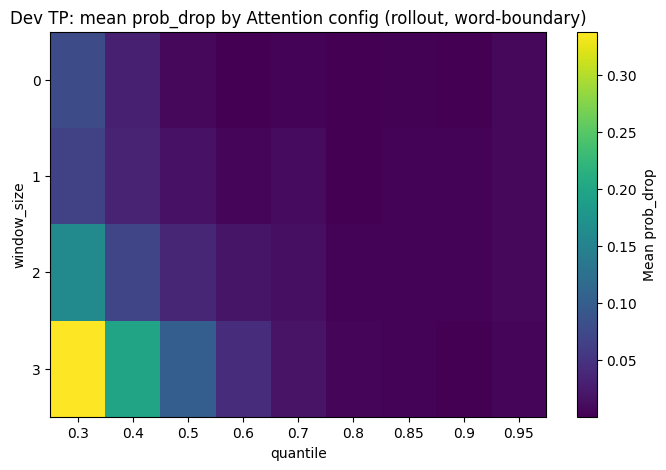

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_dev_find_config_heatmap_rollout_word_boundary.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.079340,0.030467,0.007232,0.001291,0.003713,0.000366,0.002090,0.001461,0.007250
1,0.065934,0.033003,0.017052,0.005012,0.009717,0.000776,0.004207,0.003338,0.007706
2,0.160618,0.070645,0.036913,0.019722,0.014370,0.003712,0.003534,0.003475,0.007471
3,0.337927,0.197774,0.101550,0.043042,0.018609,0.005515,0.003143,0.000400,0.006743


In [42]:
for method in sorted(dev_config_summary_word_boundary["attention_method"].unique()):
    method_df = dev_config_summary_word_boundary[
        dev_config_summary_word_boundary["attention_method"] == method
    ].copy()
    
    heatmap_data = method_df.pivot(
        index="window_size",
        columns="quantile",
        values="mean_prob_drop"
    )
    
    plt.figure(figsize=(8, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label="Mean prob_drop")
    
    plt.xticks(
        ticks=np.arange(len(heatmap_data.columns)),
        labels=heatmap_data.columns
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index
    )
    
    plt.xlabel("quantile")
    plt.ylabel("window_size")
    plt.title(f"Dev TP: mean prob_drop by Attention config ({method}, word-boundary)")
    
    plot_path = WORD_BOUNDARY_OUTPUT_DIR / f"attention_dev_find_config_heatmap_{method}_word_boundary.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)
    display(heatmap_data)

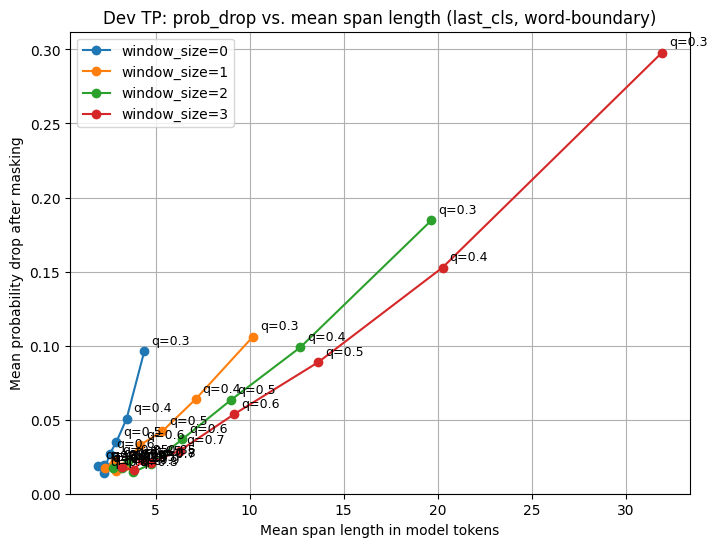

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_dev_prob_drop_vs_mean_span_len_last_cls_word_boundary.png


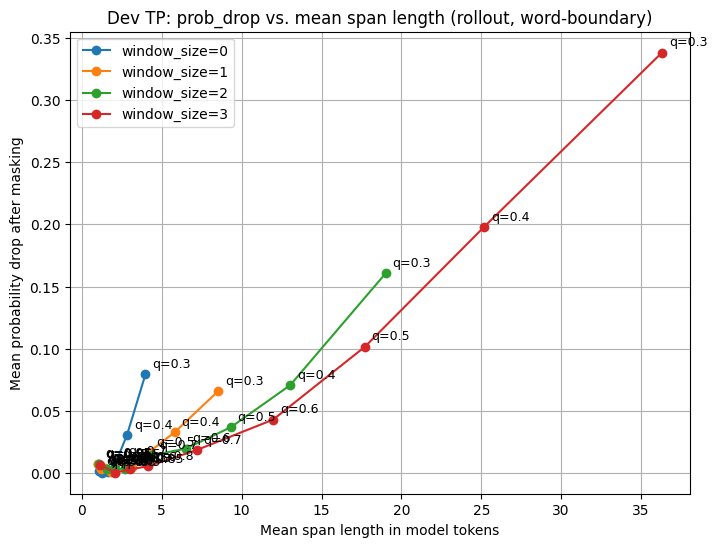

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_dev_prob_drop_vs_mean_span_len_rollout_word_boundary.png


In [43]:
for method in sorted(dev_config_summary_word_boundary["attention_method"].unique()):
    method_df = dev_config_summary_word_boundary[
        dev_config_summary_word_boundary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_span_len_tokens"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_span_len_tokens"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean span length in model tokens")
    plt.ylabel("Mean probability drop after masking")
    plt.title(f"Dev TP: prob_drop vs. mean span length ({method}, word-boundary)")
    plt.grid(True)
    plt.legend()
    
    plot_path = WORD_BOUNDARY_OUTPUT_DIR / f"attention_dev_prob_drop_vs_mean_span_len_{method}_word_boundary.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

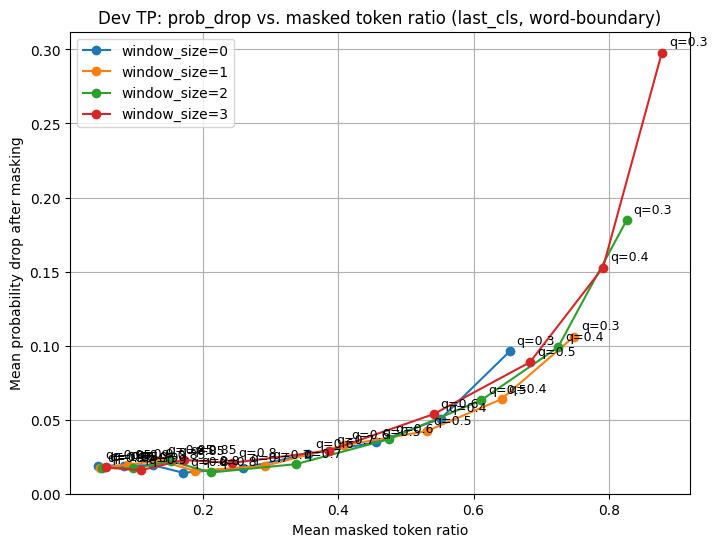

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_dev_prob_drop_vs_masked_token_ratio_last_cls_word_boundary.png


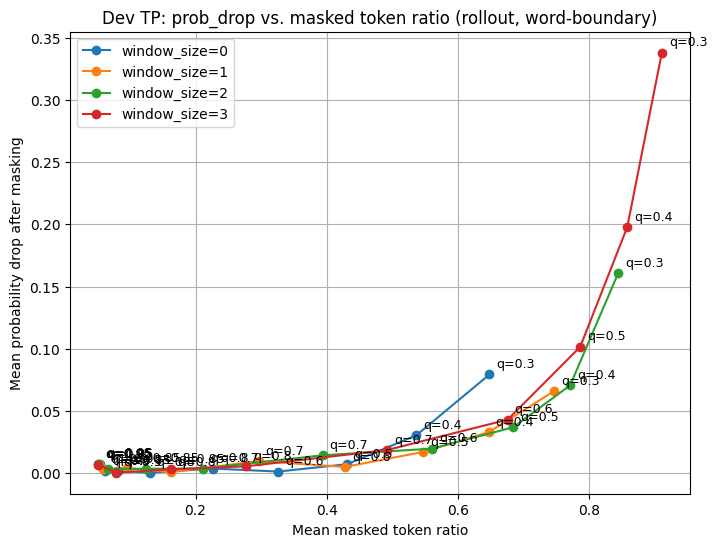

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_dev_prob_drop_vs_masked_token_ratio_rollout_word_boundary.png


In [44]:
for method in sorted(dev_config_summary_word_boundary["attention_method"].unique()):
    method_df = dev_config_summary_word_boundary[
        dev_config_summary_word_boundary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Mean probability drop after masking")
    plt.title(f"Dev TP: prob_drop vs. masked token ratio ({method}, word-boundary)")
    plt.grid(True)
    plt.legend()
    
    plot_path = WORD_BOUNDARY_OUTPUT_DIR / f"attention_dev_prob_drop_vs_masked_token_ratio_{method}_word_boundary.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

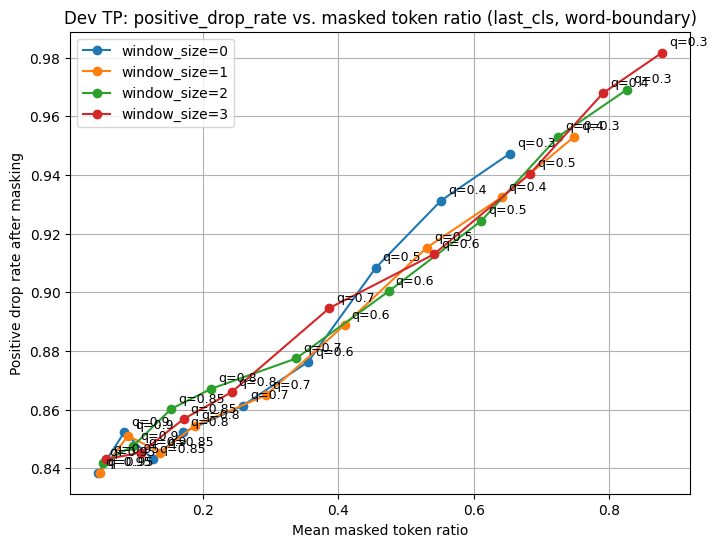

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_dev_positive_drop_rate_vs_masked_token_ratio_last_cls_word_boundary.png


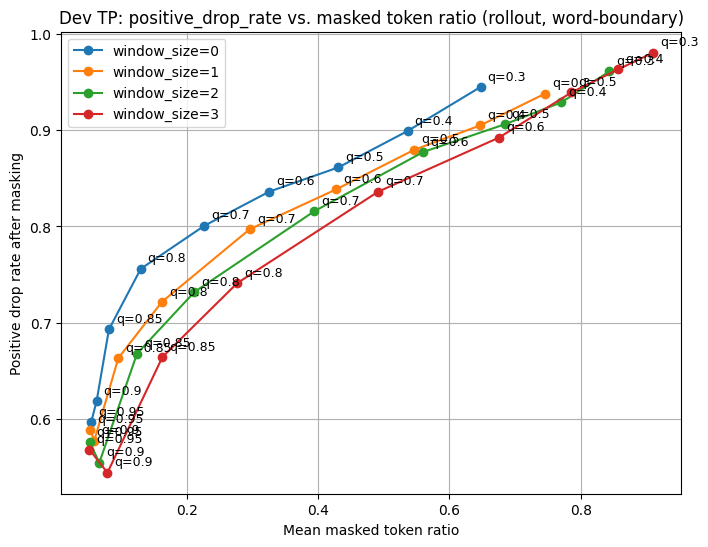

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_dev_positive_drop_rate_vs_masked_token_ratio_rollout_word_boundary.png


In [45]:
for method in sorted(dev_config_summary_word_boundary["attention_method"].unique()):
    method_df = dev_config_summary_word_boundary[
        dev_config_summary_word_boundary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["positive_drop_rate"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_masked_token_ratio"], row["positive_drop_rate"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Positive drop rate after masking")
    plt.title(f"Dev TP: positive_drop_rate vs. masked token ratio ({method}, word-boundary)")
    plt.grid(True)
    plt.legend()
    
    plot_path = WORD_BOUNDARY_OUTPUT_DIR / f"attention_dev_positive_drop_rate_vs_masked_token_ratio_{method}_word_boundary.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

In [46]:
# Final config after repeating validation with word-boundary post-processing.
# Set these values based on the plots and summary above.

BEST_ATTENTION_METHOD = "last_cls"
BEST_QUANTILE = 0.6
BEST_WINDOW_SIZE = 3

selected_config_summary_word_boundary = dev_config_summary_word_boundary[
    (dev_config_summary_word_boundary["attention_method"] == BEST_ATTENTION_METHOD) &
    (dev_config_summary_word_boundary["quantile"] == BEST_QUANTILE) &
    (dev_config_summary_word_boundary["window_size"] == BEST_WINDOW_SIZE)
]

display(selected_config_summary_word_boundary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,mean_masked_token_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_attention,mean_span_score_mean_attention,prob_drop_per_masked_token,prob_drop_per_masked_ratio
30,last_cls,3,0.6,873,0.053724,0.002402,0.178604,0.912944,0.20504,0.12142,...,0.541153,4723,9.181452,5.0,39.339191,22.0,0.12379,0.017752,0.001082,0.099277


## Final selected attention configuration

The final attention configuration is selected only after repeating the validation-based analysis with word-boundary post-processing.

This is necessary because raw attention extraction may produce punctuation-only spans or subword fragments. Since word-boundary post-processing changes the extracted spans and therefore also the perturbation-based validation scores, the final hyperparameters must be selected on the post-processed validation results rather than on the raw attention outputs.

The final configuration is therefore based on:

- raw attention scoring,
- span extraction via quantile and window size,
- word-boundary expansion,
- removal of punctuation-only artifacts,
- masking-based validation on validation true positives.

Selected final configuration:

- `attention_method = last_cls`
- `quantile = 0.95`
- `window_size = 3`

# Run best Config

In [47]:
def run_final_attention_word_boundary_on_split(df, split_name):
    """
    Run the selected raw attention configuration on one split,
    then apply word-boundary post-processing before exporting results.
    """
    positions = list(range(len(df)))
    
    raw_results = run_attention_config_on_indices(
        df=df,
        matrix_positions=positions,
        attention_methods=[BEST_ATTENTION_METHOD],
        quantile_values=[BEST_QUANTILE],
        window_size_values=[BEST_WINDOW_SIZE],
        mask_token=MASK_TOKEN
    )
    
    word_boundary_results = apply_word_boundary_to_argument_results(raw_results)
    
    argument_df = build_argument_level_df(word_boundary_results)
    span_df = build_span_level_df(word_boundary_results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return word_boundary_results, argument_df, span_df


train_results, train_argument_df, train_span_df = run_final_attention_word_boundary_on_split(
    train_df,
    "train"
)

val_results, val_argument_df, val_span_df = run_final_attention_word_boundary_on_split(
    val_df,
    "validation"
)

test_results, test_argument_df, test_span_df = run_final_attention_word_boundary_on_split(
    test_df,
    "test"
)

Building attention spans:   0%|          | 0/1533 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/96 [00:00<?, ?it/s]

Applying word-boundary post-processing:   0%|          | 0/1533 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/96 [00:00<?, ?it/s]

train argument level: (1533, 43)
train span level: (8862, 36)


...

Building attention spans:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

Applying word-boundary post-processing:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

test argument level: (438, 43)
test span level: (2555, 36)


In [48]:
final_argument_df = pd.concat(
    [train_argument_df, val_argument_df, test_argument_df],
    ignore_index=True
)

final_span_df = pd.concat(
    [train_span_df, val_span_df, test_span_df],
    ignore_index=True
)

display(final_argument_df.head())
display(final_span_df.head())

print("Final argument-level rows:", len(final_argument_df))
print("Final span-level rows:", len(final_span_df))

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 27]","[12, 36]","[0, 119]","[53, 173]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 53, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
1,1,train,2,Firefox vs internet explorer:,1,LABEL_1,0.998218,TP,True,False,...,"[That form of argument degrades this forum, an...","[1, 26, 39, 52, 62, 74]","[20, 32, 44, 56, 64, 79]","[0, 126, 170, 236, 279, 336]","[112, 142, 190, 257, 292, 361]","[""▁That"", ""▁form"", ""▁of"", ""▁argument"", ""▁degra...","[{""char_start"": 0, ""char_end"": 112, ""token_sta...","That form of argument degrades this forum, and...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
2,2,train,3,If your spouse committed murder and he or she ...,0,LABEL_0,0.969683,TN,False,False,...,"[I wouldnt turn her in becuase she is my wife,...","[1, 16, 23, 30]","[10, 16, 24, 37]","[0, 65, 90, 122]","[44, 69, 96, 150]","[""▁I"", ""▁wouldnt"", ""▁turn"", ""▁in"", ""▁becuase"",...","[{""char_start"": 0, ""char_end"": 44, ""token_star...",I wouldnt turn her in becuase she is my wife. ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
3,3,train,4,If your spouse committed murder and he or she ...,1,LABEL_1,0.998705,TP,True,False,...,"[No I wouldn't turn in my spouse, doesn't make...","[1, 20]","[9, 31]","[0, 85]","[31, 142]","[""▁No"", ""▁I"", ""'"", ""t"", ""▁turn"", ""▁my"", ""▁spou...","[{""char_start"": 0, ""char_end"": 31, ""token_star...",No I wouldn't turn in my spouse. Just because ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
4,4,train,5,Tv is better than books:,1,LABEL_1,0.998405,TP,True,False,...,[TV is terrible. Except for Spongebob maybe. T...,"[1, 26]","[12, 29]","[0, 112]","[50, 118]","[""▁TV"", ""▁is"", ""▁terrible"", ""."", ""▁Except"", ""▁...","[{""char_start"": 0, ""char_end"": 50, ""token_star...",TV is terrible. Except for Spongebob maybe. Th...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.983944,0.013089,42,17,0.404762,0.52381,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.056030,0.997032,0.983944,0.013089,42,17,0.404762,0.52381,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
2,1,train,2,Firefox vs internet explorer:,1,LABEL_1,TP,True,False,False,...,0.089694,0.998218,0.996373,0.001845,80,32,0.400000,0.58750,"That form of argument degrades this forum, and...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
3,1,train,2,Firefox vs internet explorer:,1,LABEL_1,TP,True,False,False,...,0.026695,0.998218,0.996373,0.001845,80,32,0.400000,0.58750,"That form of argument degrades this forum, and...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
4,1,train,2,Firefox vs internet explorer:,1,LABEL_1,TP,True,False,False,...,0.028637,0.998218,0.996373,0.001845,80,32,0.400000,0.58750,"That form of argument degrades this forum, and...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...


Final argument-level rows: 2191
Final span-level rows: 12692


In [49]:
final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

overall_summary = (
    final_argument_df_valid
    .groupby(["split", "attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

confusion_summary = (
    final_argument_df_valid
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

display(overall_summary)
display(confusion_summary)

,split,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,last_cls,3,0.6,438,-0.266736,0.000559,0.438141,0.513699,0.107306,0.073059,0.590803,0.857539,5.833333,53.378995,0.556520
1,train,last_cls,3,0.6,1533,-0.283452,-0.001293,0.449992,0.489237,0.110894,0.065884,0.552140,0.835592,5.780822,53.326158,0.559215
2,validation,last_cls,3,0.6,220,-0.297733,-0.021792,0.444711,0.454545,0.127273,0.068182,0.542073,0.839807,5.795455,53.986364,0.561259


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,FN,39,-0.685354,-0.866513,0.342033,0.000000,0.049637,0.734991,6.153846,64.256410,0.596015
1,test,FP,71,0.051493,0.002510,0.199544,0.802817,0.971583,0.920091,5.183099,46.380282,0.552208
2,test,TN,142,-0.698009,-0.918248,0.335139,0.007042,0.037214,0.735223,6.894366,62.338028,0.573047
3,test,TP,186,0.028816,0.002474,0.149542,0.897849,0.981553,0.952737,5.204301,46.930108,0.537267
4,train,FN,48,-0.656439,-0.812966,0.331254,0.000000,0.115294,0.771733,5.312500,49.291667,0.591733
5,train,FP,48,-0.050214,0.000644,0.169296,0.583333,0.915787,0.966001,4.833333,45.145833,0.572031
6,train,TN,652,-0.682011,-0.873811,0.338394,0.003067,0.030158,0.712169,6.312883,58.720859,0.578618
7,train,TP,785,0.056125,0.002443,0.181368,0.917197,0.990161,0.934035,5.425478,49.592357,0.540328
8,validation,FN,36,-0.730068,-0.919175,0.333186,0.000000,0.040577,0.770645,7.027778,63.166667,0.565715
9,validation,FP,30,0.074884,0.003144,0.196874,0.766667,0.968821,0.893936,5.100000,47.966667,0.563787


In [50]:
test_argument_df_valid = test_argument_df[
    test_argument_df["error"].isna()
].copy()

test_overall_summary = (
    test_argument_df_valid
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

test_confusion_summary = (
    test_argument_df_valid
    .groupby("confusion_type")
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values("confusion_type")
)

display(test_overall_summary)
display(test_confusion_summary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,last_cls,3,0.6,438,-0.266736,0.000559,0.438141,0.513699,0.107306,0.073059,0.590803,0.857539,5.833333,53.378995,0.55652


,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,FN,39,-0.685354,-0.866513,0.342033,0.000000,0.049637,0.734991,6.153846,64.256410,0.596015
1,FP,71,0.051493,0.002510,0.199544,0.802817,0.971583,0.920091,5.183099,46.380282,0.552208
2,TN,142,-0.698009,-0.918248,0.335139,0.007042,0.037214,0.735223,6.894366,62.338028,0.573047
3,TP,186,0.028816,0.002474,0.149542,0.897849,0.981553,0.952737,5.204301,46.930108,0.537267


In [51]:
final_output_dir = OUTPUT_DIR / "attention_results_word_boundary" 
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_span_level.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"attention_final_test_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_summary.csv"
)

jsonl_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.jsonl"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_overall_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

all_results = train_results + val_results + test_results

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in all_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)
print(jsonl_path)

Saved:
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.6_window3_argument_level.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.6_window3_span_level.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.6_window3_overall_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.6_window3_confusion_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/attention_results_multi_mask/attention_results_word_boundary/attention_final_test_last_cls_q0.6_window

In [52]:
# Best test examples by probability drop
tmp = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp))):
    show_attention_example(tmp, index=i)

In [53]:
# Test examples with the smallest or negative probability drops
tmp_low = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_low))):
    show_attention_example(tmp_low, index=i)